<a href="https://colab.research.google.com/github/rahulm8132/CSL701-CE25_Machine-Learning-Lab/blob/main/ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Python environment is ready!")


NumPy version: 2.0.2
Matplotlib version: 3.10.0
Python environment is ready!


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [14]:

df = pd.read_csv("cardekho_dataset.csv")

print("First 5 records:")
display(df.head())

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

numerical_attributes = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_attributes = df.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical attributes:")
print(numerical_attributes)
print("\nCategorical attributes:")
print(categorical_attributes)

print("\nTarget variable: selling_price")
display(df["selling_price"].head())


First 5 records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


Number of rows: 15411
Number of columns: 14

Column names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Numerical attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target variable: selling_price


,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [15]:
print("Missing values in each column:")
print(df.isnull().sum())

total_missing = df.isnull().sum().sum()
print("\nTotal missing values:", total_missing)

if total_missing > 0:
    print("\nMissing values found. Removing incomplete records...")
    df = df.dropna().reset_index(drop=True)
    print("Incomplete records removed.")
else:
    print("\nNo missing values found. No preprocessing for missing data is required.")

print("\nTotal missing values after preprocessing:", df.isnull().sum().sum())

if total_missing > 0:
    preprocessing_method = "Rows containing missing values were removed using dropna()."
else:
    preprocessing_method = "No missing values were present, so no imputation or row removal was required."
print("\nPreprocessing method used:")
print(preprocessing_method)


Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values: 0

No missing values found. No preprocessing for missing data is required.

Total missing values after preprocessing: 0

Preprocessing method used:
No missing values were present, so no imputation or row removal was required.


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [16]:
drop_cols = [c for c in ["car_name", "brand", "model", "Unnamed: 0"] if c in df.columns]
df = df.drop(columns=drop_cols)

print("Remaining columns after dropping identifier/text columns:")
print(df.columns.tolist())

y_preview = df["selling_price"].values
print("\nTarget variable preview:")
print(y_preview[:10])


Remaining columns after dropping identifier/text columns:
['vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Target variable preview:
[ 120000  550000  215000  226000  570000  350000  315000  410000 1050000
  511000]


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [17]:
categorical_features = [c for c in ["seller_type", "fuel_type", "transmission_type"] if c in df.columns]
print("Categorical variables:")
print(categorical_features)

# drop_first=True avoids the dummy-variable trap (perfect multicollinearity),
# and get_dummies avoids imposing a false ordinal ranking on categories.
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True, dtype=float)

print("\nTransformed dataset:")
display(df_encoded.head())
print("\nData types after encoding:")
print(df_encoded.dtypes)

predictor_columns = [c for c in df_encoded.columns if c != "selling_price"]
all_numeric = df_encoded[predictor_columns].select_dtypes(exclude=np.number).shape[1] == 0
print("\nAre all predictors numerical?", all_numeric)


Categorical variables:
['seller_type', 'fuel_type', 'transmission_type']

Transformed dataset:


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,5,20000,18.90,1197,82.00,5,550000,1.0,0.0,0.0,0.0,0.0,1.0,1.0
2,11,60000,17.00,1197,80.00,5,215000,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,9,37000,20.92,998,67.10,5,226000,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,6,30000,22.77,1498,98.59,5,570000,0.0,0.0,1.0,0.0,0.0,0.0,1.0



Data types after encoding:
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
selling_price                     int64
seller_type_Individual          float64
seller_type_Trustmark Dealer    float64
fuel_type_Diesel                float64
fuel_type_Electric              float64
fuel_type_LPG                   float64
fuel_type_Petrol                float64
transmission_type_Manual        float64
dtype: object

Are all predictors numerical? True


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [18]:
if "vehicle_age" in df_encoded.columns:
    df_encoded["Car_Age"] = df_encoded["vehicle_age"]

    print("First 10 Car_Age values:")
    display(df_encoded[["vehicle_age", "Car_Age"]].head(10))

    print("\nMinimum Car_Age:", df_encoded["Car_Age"].min())
    print("Maximum Car_Age:", df_encoded["Car_Age"].max())
    print("Average Car_Age:", df_encoded["Car_Age"].mean())
    print("\nNumber of negative ages:", (df_encoded["Car_Age"] < 0).sum())

    df_encoded = df_encoded.drop(columns=["vehicle_age"])
    print("\nDecision: vehicle_age dropped — Car_Age carries the same information.")



First 10 Car_Age values:


,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6
5,8,8
6,8,8
7,3,3
8,2,2
9,4,4



Minimum Car_Age: 0
Maximum Car_Age: 29
Average Car_Age: 6.0363376808772955

Number of negative ages: 0

Decision: vehicle_age dropped — Car_Age carries the same information.


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

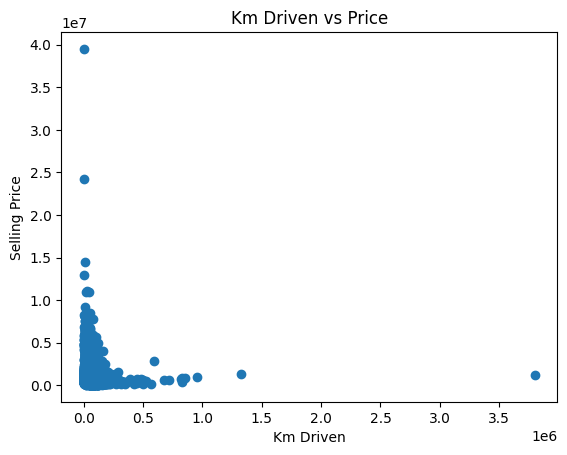

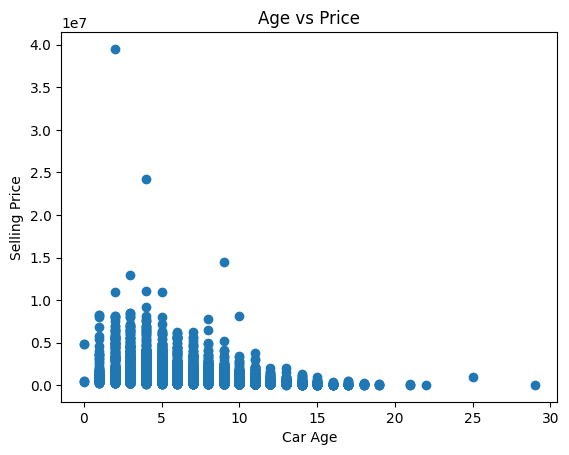

In [21]:
plt.scatter(df_encoded["km_driven"], df_encoded["selling_price"])
plt.xlabel("Km Driven"); plt.ylabel("Selling Price"); plt.title("Km Driven vs Price")
plt.show()

plt.scatter(df_encoded["Car_Age"], df_encoded["selling_price"])
plt.xlabel("Car Age"); plt.ylabel("Selling Price"); plt.title("Age vs Price")
plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [29]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma[sigma == 0] = 1

X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma

## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [28]:
feature_cols = [c for c in df_encoded.columns if c != "selling_price"]
X_all = df_encoded[feature_cols].values.astype(float)
y_all = df_encoded["selling_price"].values.astype(float)

np.random.seed(42)
idx = np.random.permutation(len(X_all))
n_test = int(0.2 * len(X_all))
X_train, X_test = X_all[idx[n_test:]], X_all[idx[:n_test]]
y_train, y_test = y_all[idx[n_test:]], y_all[idx[:n_test]]

print(X_train.shape, X_test.shape)

(12329, 13) (3082, 13)


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [30]:
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (12329, 13) y_train: (12329,)
X_test: (3082, 13) y_test: (3082,)


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [31]:
X_train_b = np.hstack([np.ones((X_train.shape[0],1)), X_train])
X_test_b = np.hstack([np.ones((X_test.shape[0],1)), X_test])
print(X_train_b.shape, X_test_b.shape)

(12329, 14) (3082, 14)


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [32]:
def ols_fit(X, y):
    XtX = X.T @ X
    Xty = X.T @ y
    beta = np.linalg.inv(XtX) @ Xty
    return beta, XtX

## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [33]:
_, XtX = ols_fit(X_train_b, y_train)
det = np.linalg.det(XtX)
print("Determinant:", det)

Determinant: 2.0855423087803046e+54


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [34]:
beta_hat, _ = ols_fit(X_train_b, y_train)
print("Intercept:", beta_hat[0])
for name, coef in zip(feature_cols, beta_hat[1:]):
    print(name, ":", coef)

Intercept: 772127.8286966137
km_driven : -49578.841707875385
mileage : 67710.32387867587
engine : 61418.689695365254
max_power : 638656.6223211156
seats : 9189.936491633513
seller_type_Individual : 810.0383710273527
seller_type_Trustmark Dealer : -8800.50180755748
fuel_type_Diesel : -62819.89085517432
fuel_type_Electric : -2321.8289563864455
fuel_type_LPG : 18994.42819388744
fuel_type_Petrol : -60518.03278380817
transmission_type_Manual : -45231.05061741825
Car_Age : -184801.13511448848


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [35]:
coef_table = pd.DataFrame({"feature": feature_cols, "coefficient": beta_hat[1:]})
coef_table["sign"] = coef_table["coefficient"].apply(lambda x: "positive" if x > 0 else "negative")
coef_table["abs_coefficient"] = coef_table["coefficient"].abs()
coef_table = coef_table.sort_values("abs_coefficient", ascending=False)
print(coef_table)

                         feature    coefficient      sign  abs_coefficient
3                      max_power  638656.622321  positive    638656.622321
12                       Car_Age -184801.135114  negative    184801.135114
1                        mileage   67710.323879  positive     67710.323879
7               fuel_type_Diesel  -62819.890855  negative     62819.890855
2                         engine   61418.689695  positive     61418.689695
10              fuel_type_Petrol  -60518.032784  negative     60518.032784
0                      km_driven  -49578.841708  negative     49578.841708
11      transmission_type_Manual  -45231.050617  negative     45231.050617
9                  fuel_type_LPG   18994.428194  positive     18994.428194
4                          seats    9189.936492  positive      9189.936492
6   seller_type_Trustmark Dealer   -8800.501808  negative      8800.501808
8             fuel_type_Electric   -2321.828956  negative      2321.828956
5         seller_type_Ind

## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [36]:
y_pred = X_test_b @ beta_hat
print(pd.DataFrame({"Actual": y_test[:10], "Predicted": y_pred[:10]}))

      Actual     Predicted
0   190000.0  1.264075e+04
1   600000.0  5.656411e+05
2   665000.0  4.709325e+05
3  1570000.0  1.488404e+06
4   160000.0 -4.581419e+05
5   675000.0  1.093657e+06
6   465000.0  4.134947e+05
7   260000.0  3.778675e+05
8   300000.0  7.414714e+05
9   850000.0  1.787312e+06


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [37]:
residuals = y_test - y_pred
RSS = np.sum(residuals**2)
print("RSS:", RSS)

RSS: 777221112838286.5


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [38]:
TSS = np.sum((y_test - y_test.mean())**2)
R2 = 1 - RSS/TSS
print("R2:", R2)

R2: 0.6651093655444607


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


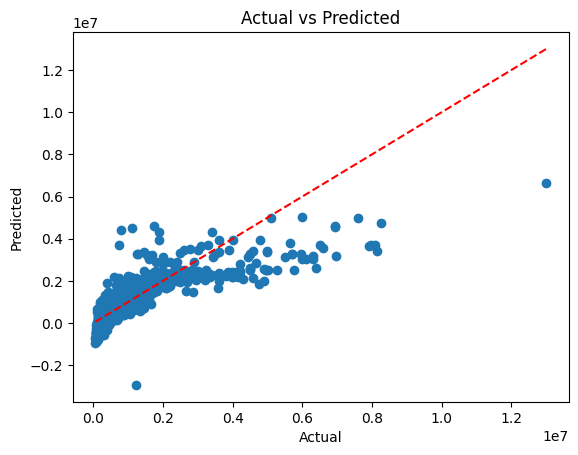

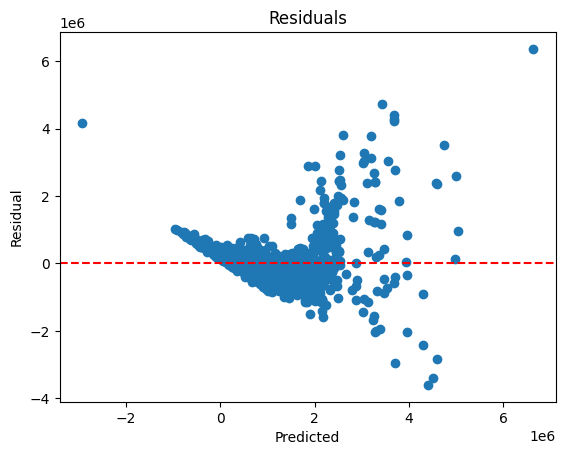

In [39]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title("Actual vs Predicted")
plt.show()

plt.scatter(y_pred, residuals)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted"); plt.ylabel("Residual"); plt.title("Residuals")
plt.show()

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.